
Object Detection & Segmentation Project

1. Data Source:
   - All dataset images are from the Kaggle dataset:
     "palakshichoksi/object-vs-no-object-in-indoor-environment".
   - To download the dataset, run:
       KaggleData_downloader.py

2. Preprocessing:
   - After downloading, execute the preprocessing scripts to prepare the images
     for training and validation.


# Object Detection Workflow

```mermaid
flowchart TD
    A[Dataset] --> B[Resize Images]
    B --> C[Extract HOG Features]
    C --> D[Train Classifier]
    D --> E[Sliding Window]
    E --> F[Predict Each Window]
    F --> G[Draw Bounding Boxes]

### import libs

In [ ]:
import cv2
import skimage
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from skimage.feature import hog
from skimage.transform import pyramid_gaussian
import random

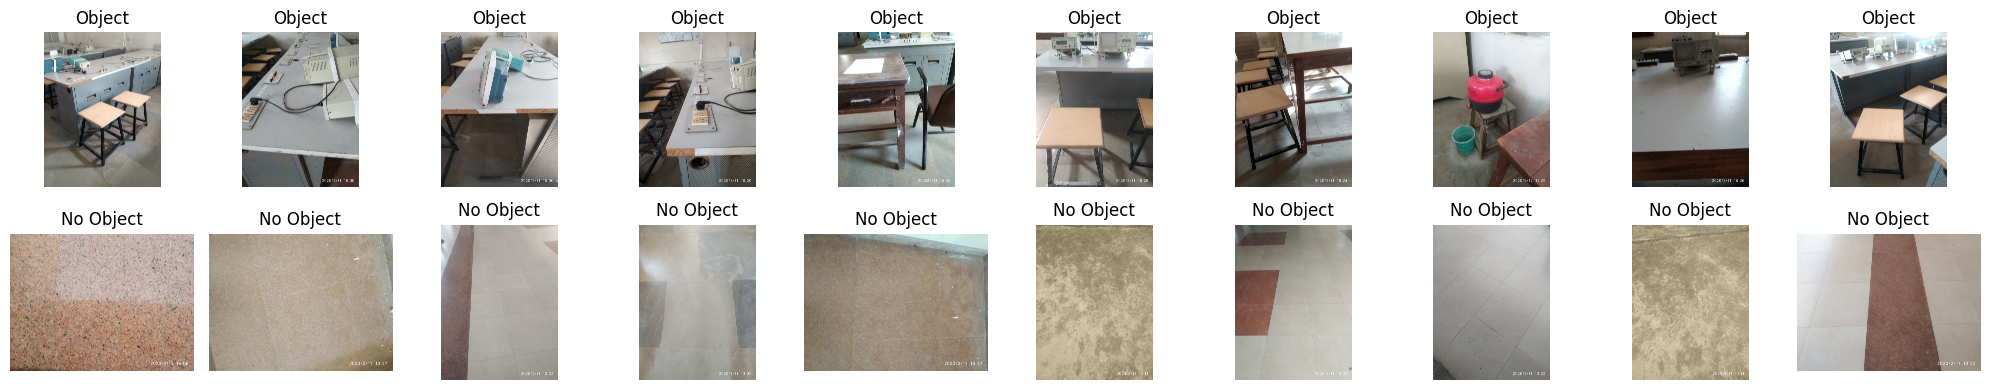

In [ ]:
import random

def show_sample_images(folder_path, num_per_class=10):
    """
    Display sample images from two classes: 'object' and 'No_object' using
    substring check for class determination.
    
    Parameters:
        folder_path (str): Path to the dataset folder containing the images.
        num_per_class (int): Number of images to show per class.
    """
    all_files = os.listdir(folder_path)
    
    object_files = []
    no_object_files = []

    for file in all_files:
        if "No_object" in file:
            no_object_files.append(file)
        elif "object" in file:
            object_files.append(file)

    object_sample = random.sample(object_files, min(num_per_class, len(object_files)))
    no_object_sample = random.sample(no_object_files, min(num_per_class, len(no_object_files)))

    samples = object_sample + no_object_sample
    labels = ["Object"]*len(object_sample) + ["No Object"]*len(no_object_sample)

    plt.figure(figsize=(20,4))
    for i, file in enumerate(samples):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2, num_per_class, i+1)
        plt.imshow(img_rgb)
        plt.title(labels[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images("../data/raw_0/", num_per_class=10)

---
### Class Split & Image Reshape

In [23]:
def analyze_and_plot_histogram(folder_path, bins=10):
    """
    Analyzes the dimensions of images and creates a histogram:
    - Images with similar dimensions are grouped into the same column/bin
    - bins: number of columns/bins in the histogram
    """
    widths = []
    heights = []
    img_names = []

    for file in os.listdir(folder_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            h, w = img.shape[:2]
            widths.append(w)
            heights.append(h)
            img_names.append(file)
    
    widths = np.array(widths)
    heights = np.array(heights)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.hist(widths, bins=bins, color='skyblue', edgecolor='black')
    plt.title("Width Distribution")
    plt.xlabel("Width")
    plt.ylabel("Number of Images")

    plt.subplot(1,2,2)
    plt.hist(heights, bins=bins, color='salmon', edgecolor='black')
    plt.title("Height Distribution")
    plt.xlabel("Height")
    plt.ylabel("Number of Images")

    plt.tight_layout()
    plt.show()

    return None

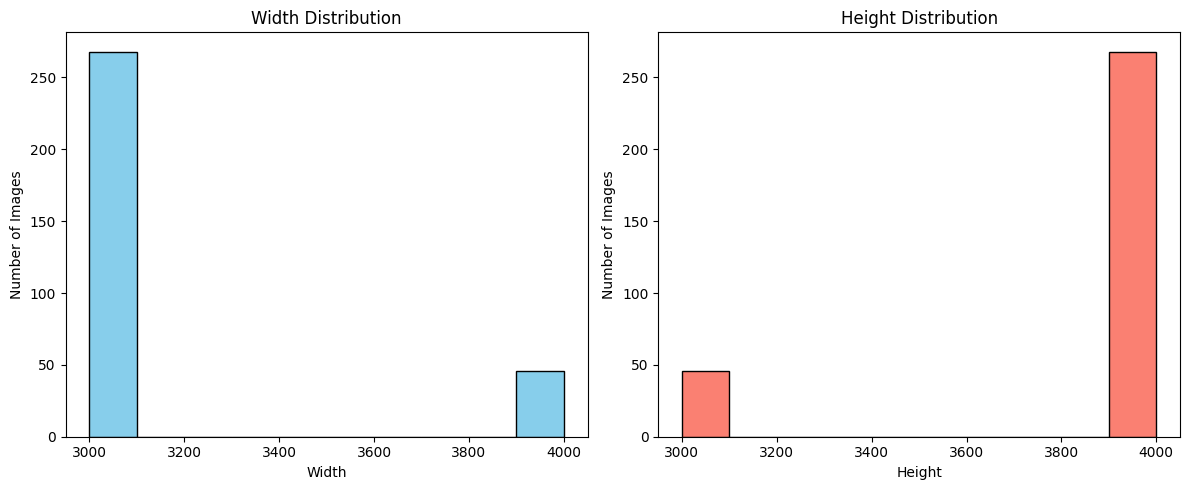

In [24]:
analyze_and_plot_histogram("../data/raw_0")

In [ ]:
import os
import cv2

def flip_large_width(folder_path, output_folder, width_threshold=4000):
    """
    - folder_path: path to the original images folder
    - output_folder: path to save the flipped images
    - width_threshold: if the width >= this value, the image will be flipped
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for file in os.listdir(folder_path):
        if not file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            continue
        
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        h, w = img.shape[:2]
        
        if w >= width_threshold:
            img = cv2.transpose(img)  # flip width <-> height

        output_path = os.path.join(output_folder, file)
        cv2.imwrite(output_path, img)
    
    print(f"Done: All processed images are saved in '{output_folder}'.")

In [28]:
folder_path = "../data/raw_0"
output_folder = "../data/same_shape_1"
flip_large_width(folder_path , output_folder , width_threshold=4000)

Done: All processed images are saved in '../data/same_shape_1'.


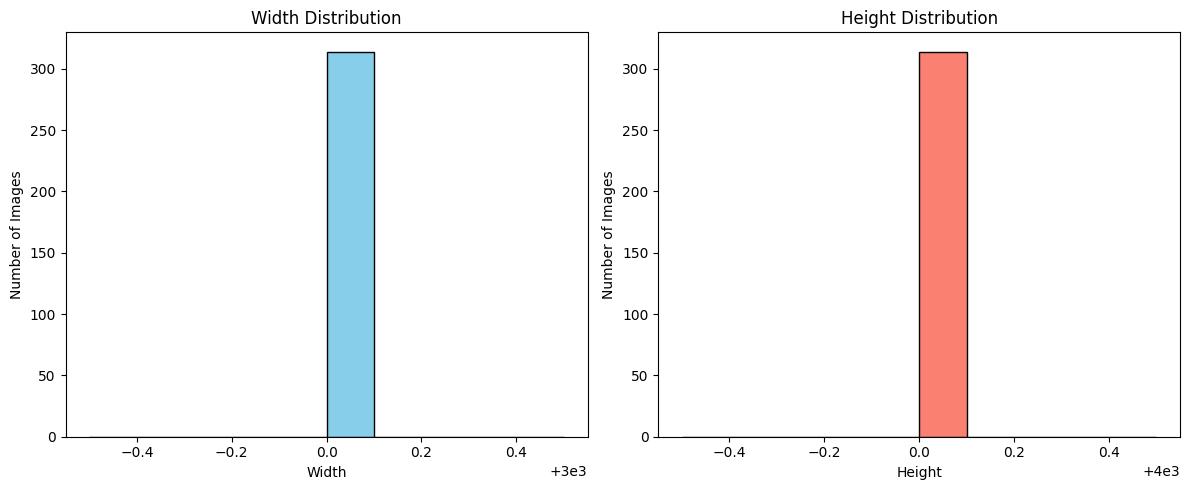

In [29]:
analyze_and_plot_histogram("../data/same_shape_1")

In [ ]:
import os
import cv2

def resize_all_images(original_folder, output_folder, size=(128,128)):
    os.makedirs(output_folder, exist_ok=True)

    for file in os.listdir(original_folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(original_folder, file)
            img = cv2.imread(img_path)
            if img is not None:
                resized_img = cv2.resize(img, size)
                cv2.imwrite(os.path.join(output_folder, file), resized_img)
    print("Resizing complete.")

original_folder = "../data/same_shape_1"
output_folder = "../data/resized_img_2"

resize_all_images(original_folder, output_folder, size=(128,128))

Resizing complete.


---
### Split Data

In [9]:
import os
import shutil

src_folder = "../data/resized_img_2"

pos_folder = "../data/classes_3/positives"
neg_folder = "../data/classes_3/negatives"

os.makedirs(pos_folder, exist_ok=True)
os.makedirs(neg_folder, exist_ok=True)

for file in os.listdir(src_folder):
    src_path = os.path.join(src_folder, file)
    
    if "No_object" in file:
        dst_path = os.path.join(neg_folder, file)
    elif "object" in file:
        dst_path = os.path.join(pos_folder, file)
    else:
        continue  

    shutil.copy(src_path, dst_path)

print("Done: Images separated into positives and negatives.")

Done: Images separated into positives and negatives.


In [10]:
import os
import shutil
from sklearn.model_selection import train_test_split

class1_folder = "../data/classes_3/positives"
class2_folder = "../data/classes_3/negatives"

base_folder = "../data/split_dataset_4"
train_folder = os.path.join(base_folder, "train")
valid_folder = os.path.join(base_folder, "valid")
test_folder  = os.path.join(base_folder, "test")

for folder in [train_folder, valid_folder, test_folder]:
    os.makedirs(os.path.join(folder, "class1"), exist_ok=True)
    os.makedirs(os.path.join(folder, "class2"), exist_ok=True)

class1_images = [os.path.join(class1_folder, f) for f in os.listdir(class1_folder) if f.lower().endswith((".jpg",".jpeg",".png"))]
class2_images = [os.path.join(class2_folder, f) for f in os.listdir(class2_folder) if f.lower().endswith((".jpg",".jpeg",".png"))]

all_images = class1_images + class2_images
all_labels = [0]*len(class1_images) + [1]*len(class2_images)

X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels, test_size=0.3, random_state=42, stratify=all_labels
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

def save_images(image_paths, labels, subset_folder):
    for img_path, label in zip(image_paths, labels):
        class_name = "class1" if label == 0 else "class2"
        dst_path = os.path.join(subset_folder, class_name, os.path.basename(img_path))
        shutil.copy(img_path, dst_path)

save_images(X_train, y_train, train_folder)
save_images(X_valid, y_valid, valid_folder)
save_images(X_test, y_test, test_folder)

print("Done! Dataset has been split into Train, Validation, and Test.")

Done! Dataset has been split into Train, Validation, and Test.


---

In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import hog

def extract_hog_features(image, resize_dim=(128,128)):
    if len(image.shape) > 2:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = cv2.resize(image, resize_dim)
    features = hog(image,
                   orientations=9,
                   pixels_per_cell=(8,8),
                   cells_per_block=(2,2),
                   block_norm='L2-Hys',
                   visualize=False)
    return features

def load_dataset_from_classfolders(folder_path, resize_dim=(128,128)):
    features_list = []
    labels_list = []
    
    class_folders = [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path,f))]
    
    for class_folder in class_folders:
        class_path = os.path.join(folder_path, class_folder)
        if class_folder.lower() == 'class1':
            label = 0
        elif class_folder.lower() == 'class2':
            label = 1
        else:
            raise ValueError(f"Unknown class folder: {class_folder}")
        
        for file in os.listdir(class_path):
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                img_path = os.path.join(class_path, file)
                img = cv2.imread(img_path)
                features = extract_hog_features(img, resize_dim)
                features_list.append(features)
                labels_list.append(label)
    
    return np.array(features_list), np.array(labels_list)

# تطبيقه على train/valid/test
train_features, train_labels = load_dataset_from_classfolders("../data/split_dataset_4/train")
valid_features, valid_labels = load_dataset_from_classfolders("../data/split_dataset_4/valid")
test_features, test_labels   = load_dataset_from_classfolders("../data/split_dataset_4/test")

print("Train features shape:", train_features.shape)
print("Valid features shape:", valid_features.shape)
print("Test features shape:", test_features.shape)

Train features shape: (219, 8100)
Valid features shape: (47, 8100)
Test features shape: (48, 8100)


---
### SVM

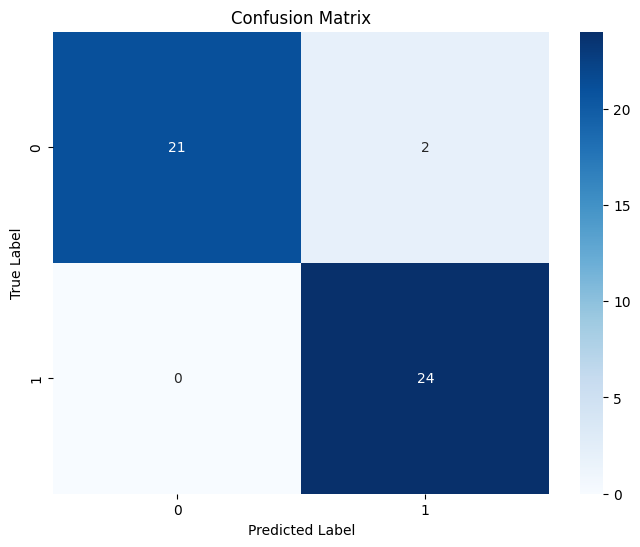

<Figure size 1600x800 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(valid_labels, valid_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

num_samples = 12
plt.figure(figsize=(16,8))
plt.show()

---
### Sliding Window

In [ ]:
import cv2
import numpy as np
from skimage.feature import hog
from skimage.transform import pyramid_gaussian
import matplotlib.pyplot as plt


In [ ]:
def pyramid(image, scale=1.5, min_size=(128,128)):
    yield image
    while True:
        w = int(image.shape[1] / scale)
        h = int(image.shape[0] / scale)
        if w < min_size[0] or h < min_size[1]:
            break
        image = cv2.resize(image, (w,h))
        yield image

In [ ]:
def sliding_window(image, step_size=32, window_size=(128,128)):
    for y in range(0, image.shape[0] - window_size[1] + 1, step_size):
        for x in range(0, image.shape[1] - window_size[0] + 1, step_size):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

In [ ]:
def detect_objects_raw(image, svm_model, window_size=(128,128), step_size=32, threshold=0.0):
    detections = []
    for resized in pyramid(image, scale=1.5, min_size=window_size):
        scale = image.shape[1] / float(resized.shape[1])
        for (x, y, window) in sliding_window(resized, step_size=step_size, window_size=window_size):
            if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]:
                continue
            gray = cv2.cvtColor(window, cv2.COLOR_BGR2GRAY)
            features = hog(gray, orientations=9, pixels_per_cell=(8,8),
                           cells_per_block=(2,2), block_norm='L2-Hys', visualize=False)
            features = features.reshape(1, -1)
            pred = svm_model.decision_function(features)
            if pred[0] > threshold:
                rx = int(x * scale)
                ry = int(y * scale)
                rw = int(window_size[0] * scale)
                rh = int(window_size[1] * scale)
                detections.append((rx, ry, rw, rh, pred[0]))
    return detections

In [ ]:
def detect_objects_nms(image, svm_model, window_size=(128,128), step_size=32, threshold=0.9):
    detections = []
    for resized in pyramid_gaussian(image, downscale=1.5, channel_axis=-1):
        if resized.shape[0] < window_size[1] or resized.shape[1] < window_size[0]:
            break
        scale_x = image.shape[1] / resized.shape[1]
        scale_y = image.shape[0] / resized.shape[0]
        for (x, y, window) in sliding_window(resized, step_size=step_size, window_size=window_size):
            if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]:
                continue
            if window.dtype != np.uint8:
                win = (window * 255).astype(np.uint8)
            else:
                win = window
            gray = cv2.cvtColor(win, cv2.COLOR_BGR2GRAY)
            features = hog(gray, orientations=9, pixels_per_cell=(8,8),
                           cells_per_block=(2,2), block_norm='L2-Hys', visualize=False)
            features = features.reshape(1, -1)
            pred_score = svm_model.decision_function(features)
            if pred_score[0] > threshold:
                x_orig = int(x * scale_x)
                y_orig = int(y * scale_y)
                w_orig = int(window_size[0] * scale_x)
                h_orig = int(window_size[1] * scale_y)
                detections.append((x_orig, y_orig, w_orig, h_orig, pred_score[0]))
    return detections

In [ ]:
def non_max_suppression(detections, overlap_thresh=0.3):
    if len(detections) == 0:
        return []
    boxes = np.array([[x, y, x+w, y+h] for (x, y, w, h, _) in detections])
    scores = np.array([s for (_, _, _, _, s) in detections])
    x1, y1, x2, y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        inter = np.maximum(0, xx2 - xx1 + 1) * np.maximum(0, yy2 - yy1 + 1)
        iou = inter / (areas[i] + areas[order[1:]] - inter)
        order = order[np.where(iou <= overlap_thresh)[0] + 1]
    return [(detections[i][0], detections[i][1], detections[i][2], detections[i][3]) for i in keep]

In [ ]:

def draw_detections(image, detections):
    output = image.copy()
    for det in detections:
        x, y, w, h = det[:4]
        cv2.rectangle(output, (x, y), (x+w, y+h), (0,255,0), 2)
    return output

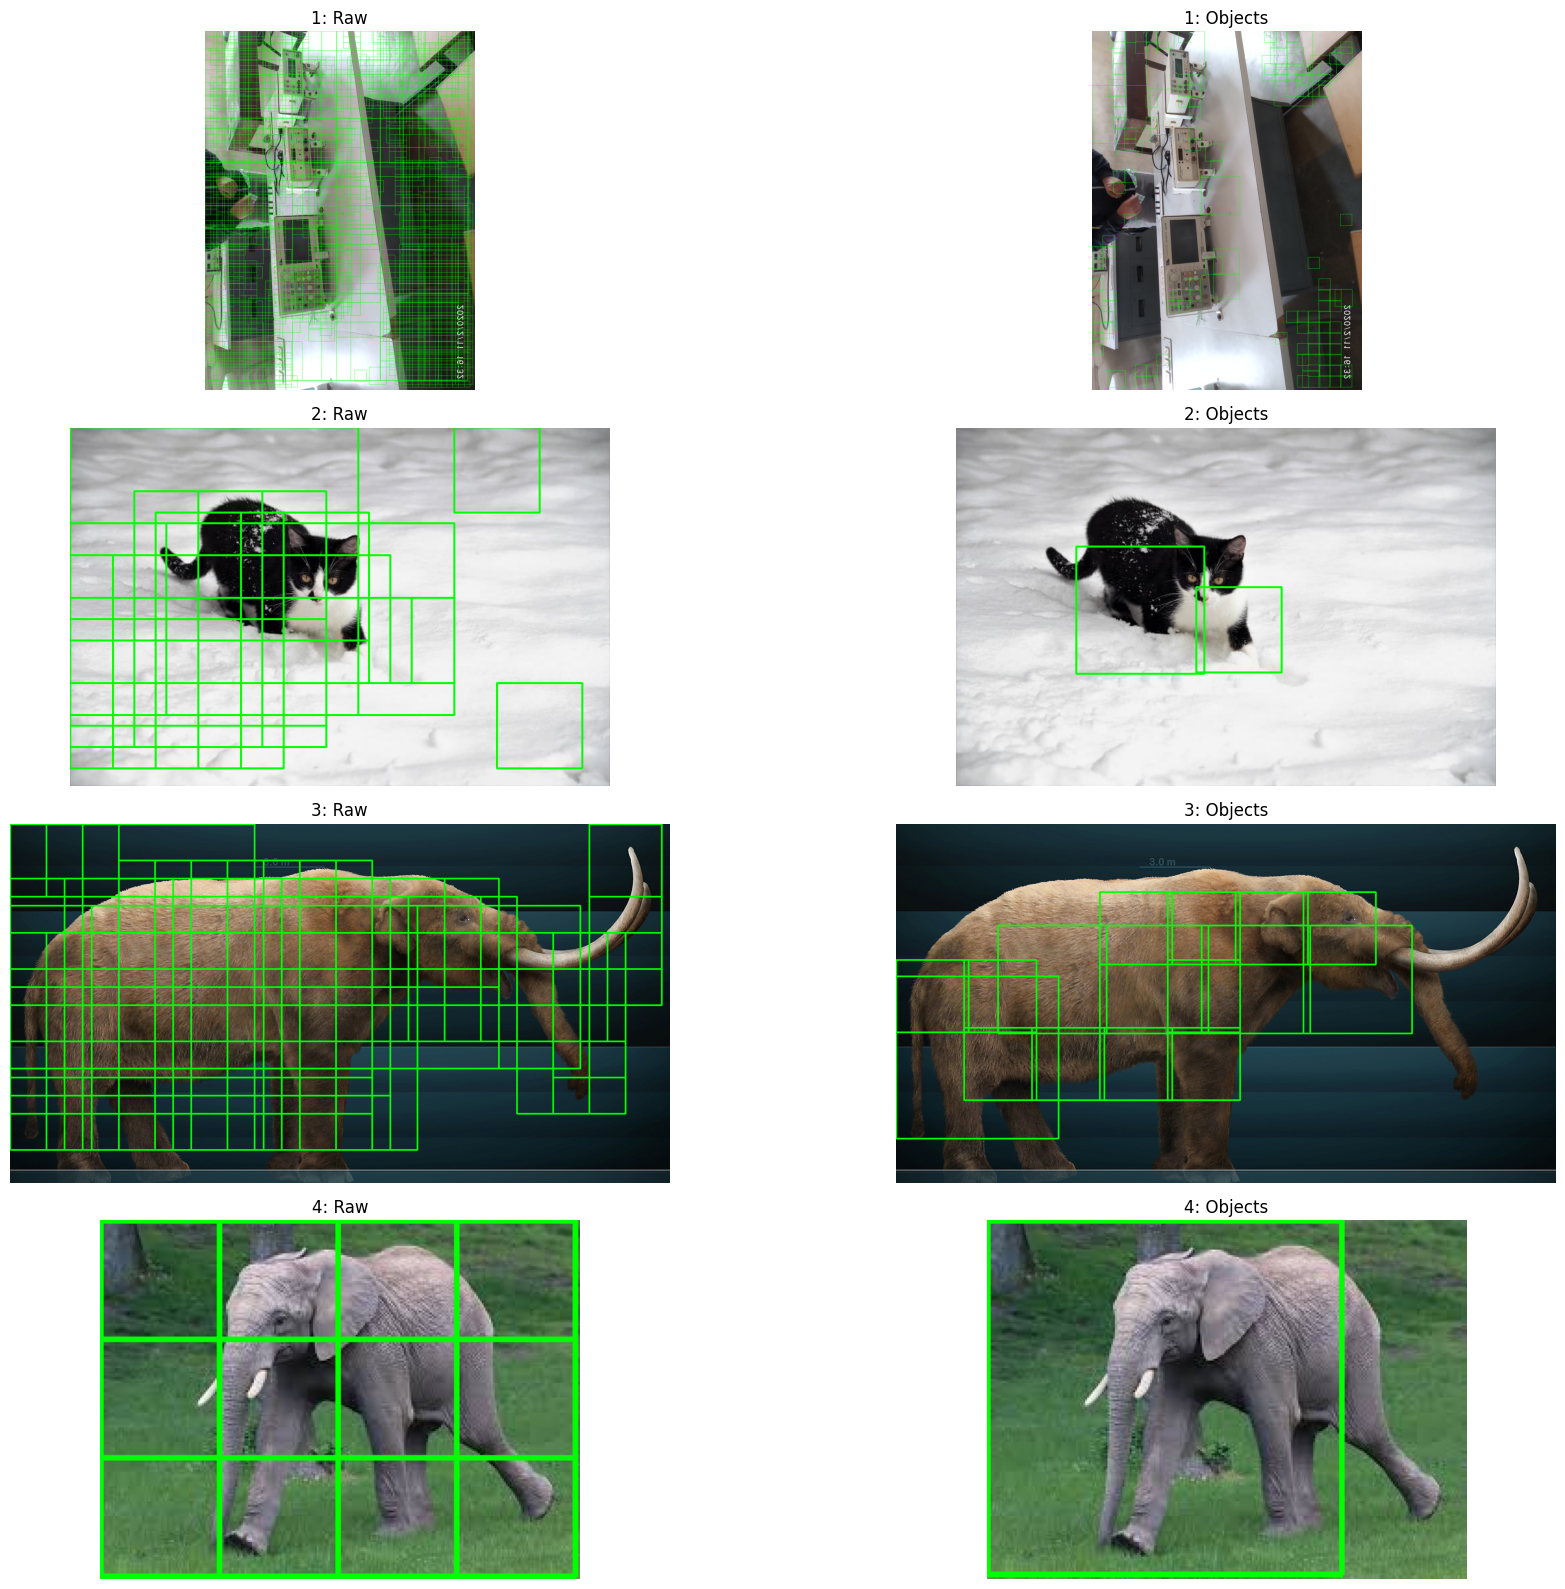

In [ ]:

image_paths = [
    "../data/same_shape_1/object.97.jpg",
    "../data/sample_data/cat.jpg",
    "../data/sample_data/Mammut.jpg",
    "../data/sample_data/images.jfif"
]

plt.figure(figsize=(20,16))

for i, img_path in enumerate(image_paths):
    image = cv2.imread(img_path)
    if image is None:
        print(f"Cannot read image: {img_path}")
        continue

    raw_detections = detect_objects_raw(image, svm_model, window_size=(128,128), step_size=64, threshold=0.0)
    raw_img = draw_detections(image.copy(), raw_detections)

    nms_dets = detect_objects_nms(image, svm_model, window_size=(128,128), step_size=120, threshold=0.9)
    nms_boxes = non_max_suppression(nms_dets, overlap_thresh=0.4)
    nms_img = draw_detections(image.copy(), nms_boxes)

    plt.subplot(4, 2, i*2 + 1)
    plt.imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
    plt.title(f"{i+1}: Raw")
    plt.axis('off')

    plt.subplot(4, 2, i*2 + 2)
    plt.imshow(cv2.cvtColor(nms_img, cv2.COLOR_BGR2RGB))
    plt.title(f"{i+1}: Objects")
    plt.axis('off')

plt.tight_layout()

plt.savefig("detections_grid.png", dpi=300)
plt.show()